In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
import dataset
from matplotlib.patches import Patch
import torch
import torch.nn as nn
from collections import OrderedDict
import sys
sys.path.append(os.path.join(os.getcwd(), "models"))
from models.unet import *
from models.majority_classifier import *
from matplotlib.colors import ListedColormap, BoundaryNorm
from utilities.utils import plot_confusion_matrix, compute_confusion_matrix
from torchview import draw_graph
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

In [2]:
ds = dataset.DFC18(split="test", normalize=True, standardize=False)

Loaded 17409 samples from test set


**Prediction Visuals**

In [3]:
def visualize_rgb_prediction_label(
    patch,
    model=None,                 # backward-compat: single model
    models=None,                # list of models
    model_captions=None,        # captions for models
    confusion=False,            # only works for one model
    vertical_label=None,
    col_titles=True
):
    """
    Multi-model RGB visualization for patches.
    Shows: Input | [Pred1 | Pred2 | ...] | Ground Truth
    Legend only shows classes present in predictions or ground truth.
    Confusion matrix is computed only if exactly one model is provided.
    """

    class_info = ds.class_info

    # Normalize models list
    if models is None:
        models = []
    if model is not None:
        models = [model] if len(models) == 0 else models
    n_models = len(models)
    if n_models == 0:
        raise ValueError("At least one model must be provided.")

    # Captions
    if model_captions is None:
        model_captions = ["Prediction"] if n_models == 1 else [f"Prediction {i+1}" for i in range(n_models)]
    assert len(model_captions) == n_models, "model_captions must match number of models"

    # ===== Input image (already RGB) =====
    image = patch['image']
    ncols = 2 + n_models  # Input + predictions + ground truth
    fig_w = max(14, 4.5 * ncols)
    fig, ax = plt.subplots(1, ncols, figsize=(fig_w, 6))
    if not isinstance(ax, np.ndarray):
        ax = np.array([ax])

    ax[0].imshow(np.transpose(image, (1, 2, 0)))
    if col_titles:
        ax[0].set_title("Input Visualization", weight="bold")
    ax[0].axis('off')

    # ===== Class colors =====
    class_colors = {}
    for class_id, (_, color) in class_info.items():
        if isinstance(color, str):  # hex to RGB
            color = color.lstrip('#')
            color = tuple(int(color[i:i+2], 16) for i in (0, 2, 4))
        class_colors[class_id] = color

    # ===== Predictions =====
    preds_rgb = []
    preds_idx = []
    for m in models:
        if m is None:
            pred = np.zeros_like(patch['label'], dtype=np.int32)
        else:
            m.eval()
            with torch.no_grad():
                input_tensor = torch.tensor(patch['image']).unsqueeze(0).to(next(m.parameters()).device)
                output = m(input_tensor)
                pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy().astype(np.int32)

        preds_idx.append(pred)

        # map to RGB
        h, w = pred.shape
        pred_rgb = np.zeros((h, w, 3), dtype=np.uint8)
        for class_id, color in class_colors.items():
            pred_rgb[pred == class_id] = color
        preds_rgb.append(pred_rgb)

    # ===== Plot predictions =====
    for i, (prgb, caption) in enumerate(zip(preds_rgb, model_captions)):
        ax[1 + i].imshow(prgb)
        if col_titles:
            ax[1 + i].set_title(caption, weight="bold")
        ax[1 + i].axis('off')

    # ===== Ground truth =====
    label = patch['label']
    h, w = label.shape
    gt_rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in class_colors.items():
        gt_rgb[label == class_id] = color
    ax[-1].imshow(gt_rgb)
    if col_titles:
        ax[-1].set_title("Ground Truth", weight="bold")
    ax[-1].axis('off')

    # ===== Legend (filtered) =====
    used_class_ids = np.unique(np.concatenate([label] + preds_idx))
    filtered_class_info = {i: class_info[i] for i in used_class_ids if i in class_info}
    legend_elements = []
    for name, color in filtered_class_info.values():
        if isinstance(color, str):
            color = color.lstrip('#')
            color = tuple(int(color[i:i+2], 16) for i in (0, 2, 4))
        color = np.array(color, dtype=float) / 255.0
        legend_elements.append(Patch(facecolor=color, edgecolor='black', label=name))
    legend_elements.append(Patch(facecolor='white', edgecolor='white', label=' '*40))
    if legend_elements:
        legend = plt.legend(
            handles=legend_elements,
            loc='upper left',
            bbox_to_anchor=(1.05, 1),
            title="Classes (predicted only)",
            fontsize=12,
            handlelength=1.5,
            handletextpad=0.5,
            borderpad=0.5,
            labelspacing=0.5,
            frameon=True
        )
        legend.get_title().set_fontsize(12)
        legend.get_title().set_fontweight('bold')

    # ===== Vertical label =====
    if vertical_label is not None:
        bbox = ax[0].get_position()
        y_center = bbox.y0 + bbox.height / 2 + 0.1 # MANUALLY ADJUSTED ONLY FOR LARGE LEGEND
        fig.text(0.0, y_center, vertical_label, va='center', ha='center',
                 rotation='vertical', fontsize=12, weight='bold')

    plt.tight_layout(rect=[0, 0, 0.90, 1])
    plt.show()

    # ===== Confusion matrix only for single model =====
    if confusion and n_models == 1:
        pred_idx = preds_idx[0]
        true_mask = label
        valid_mask = true_mask != 0
        y_true = true_mask[valid_mask]
        y_pred = pred_idx[valid_mask]
        cm = compute_confusion_matrix(y_true, y_pred, max(class_info.keys()) + 1)
        plot_confusion_matrix(cm, class_info)


(3, 256, 256)
UH_NAD83_271460_3289689_x0_y10752
[0 8]
8


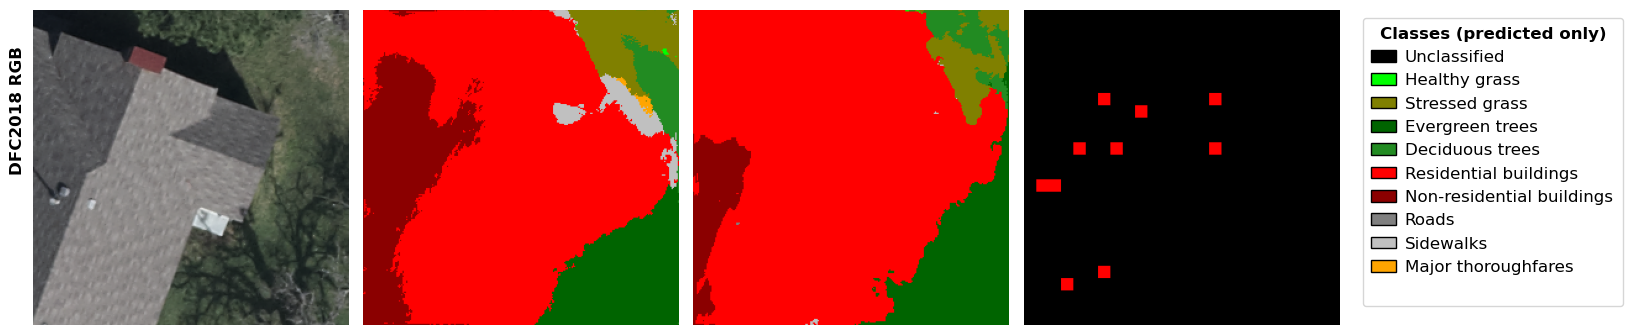

In [5]:
patch_index = 3  #  3,57,1,48,54
patch = ds.__getitem__(patch_index)
print(patch["image"].shape)
print(patch["id"])
print(np.unique(patch["label"]))
print(patch["majority_class"])

# --- Load 3 segmentation models ---
m_1 = UNetBase(n_channels=3)
m_1.load_state_dict(torch.load('trained_models/segmentation/unet_base.pth'))

m_2 = UNetBaseBig(n_channels=3)
m_2.load_state_dict(torch.load('trained_models/segmentation/unet_base_big.pth'))

#m_3 = UNetRF1(n_channels=3)
#m_3.load_state_dict(torch.load('trained_models/segmentation/unet_pool0_1x1.pth'))

# --- Visualize 3 models side by side ---
visualize_rgb_prediction_label(
    patch,
    models=[m_1, m_2],
    model_captions=["Base", "Base-Large"],
    confusion=False,                            # ignored for multi-model
    vertical_label="DFC2018 RGB",
    col_titles=False # for thesis visual
)

In [4]:
def visualize_rgb_grid(patch_indices, ds, show_gt=True, row_label_positions=None):
    class_info = ds.class_info
    n_images = len(patch_indices)
    n_rows = 1 + int(show_gt)  # RGB + optional GT

    fig, axes = plt.subplots(n_rows, n_images, figsize=(3.5 * n_images, 3.5 * n_rows), squeeze=False)

    for col, idx in enumerate(patch_indices):
        patch = ds.__getitem__(idx)
        image = patch['image']  # (C,H,W)
        rgb_img = np.transpose(image, (1, 2, 0))
        axes[0, col].imshow(rgb_img)
        axes[0, col].axis('off')
        #axes[0, col].set_title(f"Patch {idx}")

        if show_gt:
            label = patch['label'].astype(np.int32)

            id_to_color = np.zeros((max(class_info.keys()) + 1, 3), dtype=np.uint8)
            for class_id, (_, color) in class_info.items():
                id_to_color[class_id] = color
            label_rgb = id_to_color[label]

            axes[1, col].imshow(label_rgb)
            axes[1, col].axis('off')

    # Default manual vertical positions if not provided
    if row_label_positions is None:
        if show_gt:
            row_label_positions = {'RGB': 0.755, 'Reference': 0.365}
        else:
            row_label_positions = {'RGB': 0.54}

    # Add vertical row labels on the left side with manual vertical positions
    for label, y_pos in row_label_positions.items():
        fig.text(
            0.095,       # horizontal position (left of grid)
            y_pos,      # vertical position manually adjusted
            label,
            va='center',
            ha='center',
            rotation='vertical',
            fontsize=12,
            weight='bold'
        )

    # Legend below grid, two rows
    legend_elements = [
        Patch(facecolor=np.array(color) / 255.0, edgecolor='black', label=name)
        for name, color in class_info.values()
    ]
    legend_box = fig.add_axes([0.125, 0.03, 0.8, 0.12])  # position near bottom
    legend_box.axis('off')
    legend = legend_box.legend(
        handles=legend_elements,
        loc='center',
        ncol=(len(legend_elements) + 1) // 2,
        fontsize=9,
        handlelength=1.5,
        handletextpad=0.6,
        columnspacing=1.2,
        title="Classes",
        title_fontsize=10,
        frameon=True,
        borderpad=1,
    )
    #legend.get_title().set_fontsize(12)
    legend.get_title().set_fontweight('bold')

    plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.18, wspace=0.05, hspace=0.05)
    plt.show()

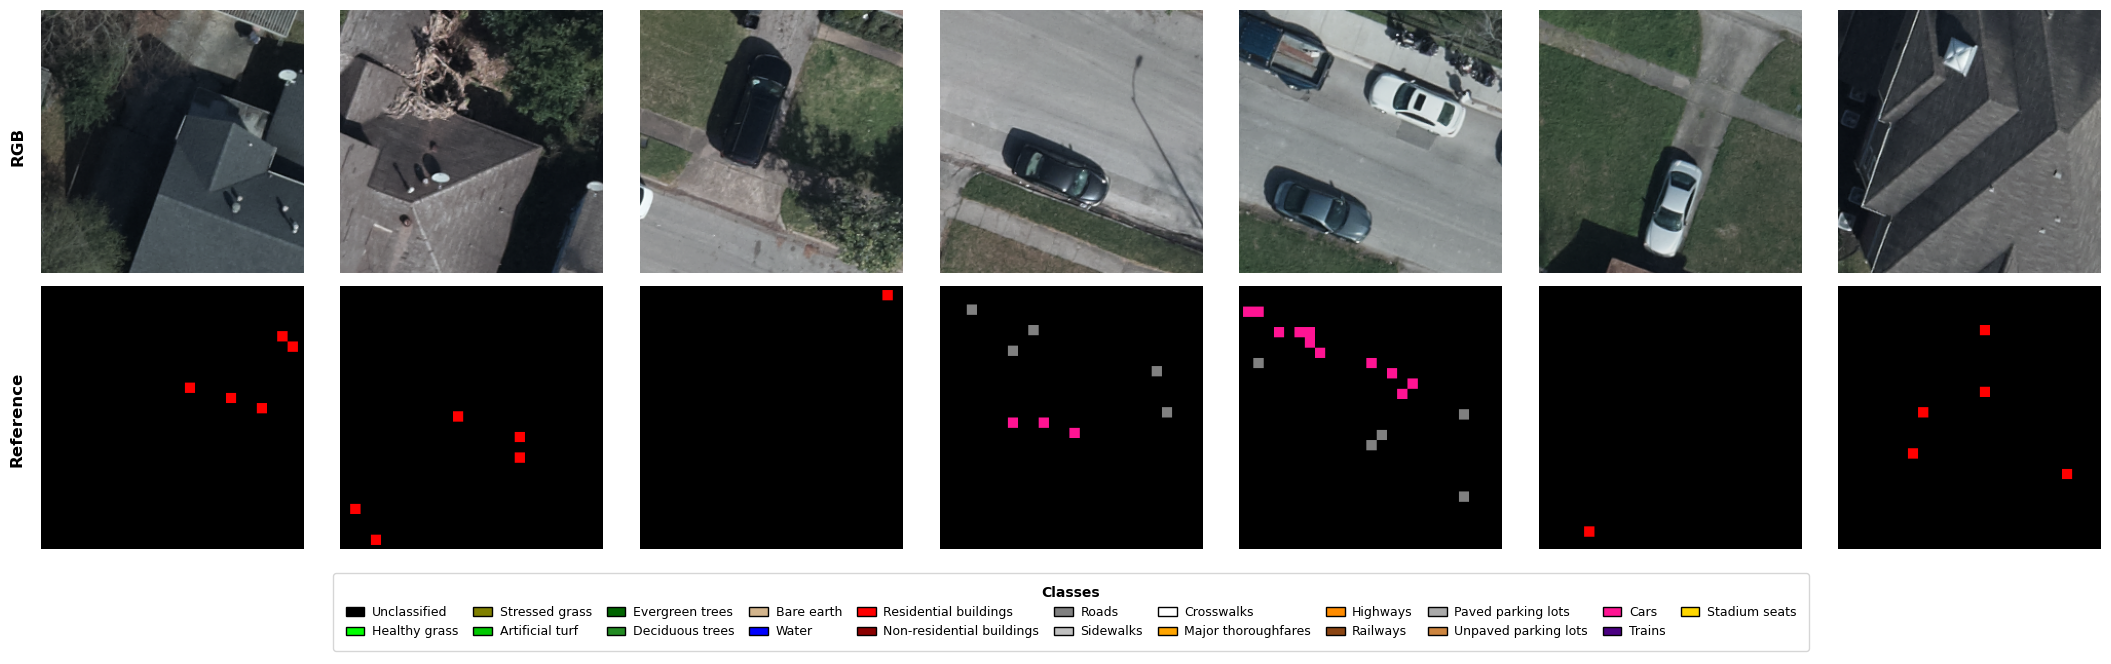

In [27]:
#patch_indices = [3,57,1,48,54]  # keep 3,57,1,48,54 | bis 70 geschaut
patch_indices = [31, 37, 81, 82, 135, 136, 188] #31, 37, 81, 82, 135, 136, 188
visualize_rgb_grid(patch_indices, ds, show_gt=True)


In [3]:
def visualize_single_patch(idx, ds):
    patch = ds.__getitem__(idx)
    image = patch['image']  # (C,H,W)
    rgb_img = np.transpose(image, (1, 2, 0))

    plt.imshow(rgb_img)
    plt.axis('off')
    plt.show()

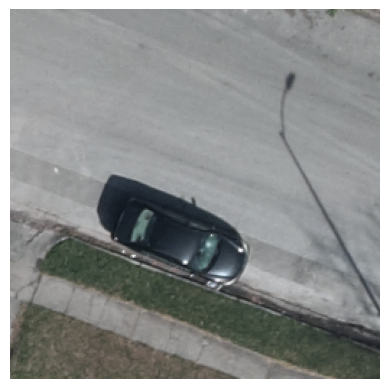

In [6]:
visualize_single_patch(82, ds)

**Receptive Field Visuals**

In [10]:
def compute_receptive_field(model, input_shape=(1, 13, 256, 256), output_pos=(0, 0, 128, 128), visualize=True):
    model.eval()
    x = torch.zeros(input_shape, requires_grad=True)

    # Forward pass
    out = model(x)

    # Create mask with 1s at the given spatial position for ALL channels
    mask = torch.zeros_like(out)
    batch_idx, _, y, x_pos = output_pos
    mask[batch_idx, :, y, x_pos] = 1.0  # all channels at this spatial location

    # Backward pass from the selected output pixel (all channels)
    out.backward(gradient=mask)

    # Sum absolute gradients over input channels to get influence map (H, W)
    grad_mask = x.grad[0].abs().sum(dim=0)  # sum over input channels

    # Compute total receptive field (all non-zero gradients)
    influenced_coords = torch.nonzero(grad_mask > 0, as_tuple=False)
    if len(influenced_coords) == 0:
        rf_size = (0, 0)
    else:
        min_yx = influenced_coords.min(dim=0).values
        max_yx = influenced_coords.max(dim=0).values    
        rf_size = (int(max_yx[0] - min_yx[0] + 1), int(max_yx[1] - min_yx[1] + 1))

    # Compute ERF.01
    threshold_01 = 0.01 * grad_mask.max()
    effective_coords_01 = torch.nonzero(grad_mask > threshold_01, as_tuple=False)
    print(f"Pixels above 0.01 threshold: {effective_coords_01.shape[0]}")
    if len(effective_coords_01) == 0:
        erf_01 = (0, 0)
    else:
        min_yx_eff_01 = effective_coords_01.min(dim=0).values
        max_yx_eff_01 = effective_coords_01.max(dim=0).values
        erf_01 = (int(max_yx_eff_01[0] - min_yx_eff_01[0] + 1), int(max_yx_eff_01[1] - min_yx_eff_01[1] + 1))

    # Compute ERF.25
    threshold_25 = 0.25 * grad_mask.max()
    effective_coords_25 = torch.nonzero(grad_mask > threshold_25, as_tuple=False)
    print(f"Pixels above 0.25 threshold: {effective_coords_25.shape[0]}")
    if len(effective_coords_25) == 0:
        erf_25 = (0, 0)
    else:
        min_yx_eff_25 = effective_coords_25.min(dim=0).values
        max_yx_eff_25 = effective_coords_25.max(dim=0).values
        erf_25 = (int(max_yx_eff_25[0] - min_yx_eff_25[0] + 1), int(max_yx_eff_25[1] - min_yx_eff_25[1] + 1))

    # Visualization
    if visualize:
        print("Non-zero gradient pixels:", torch.nonzero(grad_mask > 0).shape[0])
        print("Gradient map max:", grad_mask.max().item())
        print("Gradient map min:", grad_mask.min().item())
        grad_log = np.log1p(grad_mask.detach().cpu().numpy() * 100)  # scale for visibility
        plt.imshow(grad_log, cmap='hot', interpolation='none')
        plt.title('Receptive Field Heatmap')
        plt.colorbar()
        plt.show()

    print(f"Receptive field size: {rf_size}")
    print(f"Effective receptive field size (ERF.01): {erf_01}")
    print(f"Effective receptive field size (ERF.25): {erf_25}")

    return rf_size, erf_01, erf_25, grad_mask


Pixels above 0.01 threshold: 540
Pixels above 0.25 threshold: 27
Non-zero gradient pixels: 42025
Gradient map max: 29.060747146606445
Gradient map min: 0.0


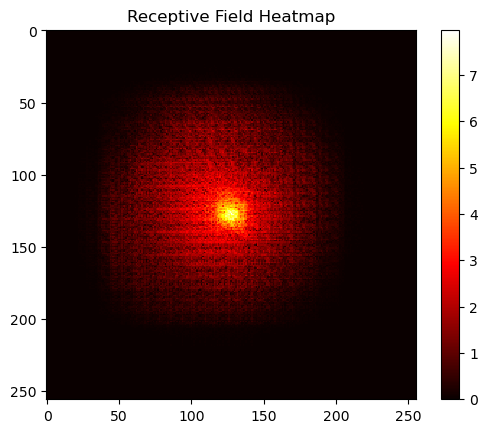

Receptive field size: (205, 205)
Effective receptive field size (ERF.01): (32, 34)
Effective receptive field size (ERF.25): (7, 8)


In [11]:
model_path = 'trained_models/segmentation/unet_base.pth'
model = UNetBase(n_channels=3)  # n_channels based on model
model.load_state_dict(torch.load(model_path))
input_shape=(1, 3, 256, 256)
output_pos=(0, 0, 128, 128)
#input_shape=(1, 4, 17, 17)
#output_pos=(0, 0, 9, 9)
rf_size, erf_01, erf_20, grad_mask = compute_receptive_field(model, input_shape, output_pos) # should output of this be symmetric?

In [5]:
def compute_receptive_field_grid(models, titles, input_shape=(1, 3, 256, 256), output_pos=(0, 0, 128, 128)):
    grad_masks = []
    rf_results = []

    for model in models:
        model.eval()
        x = torch.zeros(input_shape, requires_grad=True)
        out = model(x)

        # Use all output channels at the selected (h, w) position
        mask = torch.zeros_like(out)
        mask[0, :, output_pos[2], output_pos[3]] = 1.0  # sets all channels to 1

        out.backward(gradient=mask)
        grad_mask = x.grad[0].abs().sum(dim=0)  # (H, W)
        print(f"{titles[len(grad_masks)]} - Max gradient value: {grad_mask.max().item()}")

        grad_masks.append(grad_mask.detach().cpu().numpy())

        # Compute RF, ERF.01, ERF.25
        influenced_coords = torch.nonzero(grad_mask > 0, as_tuple=False)
        rf_size = (0, 0) if len(influenced_coords) == 0 else tuple(
            (influenced_coords.max(dim=0).values - influenced_coords.min(dim=0).values + 1).int().tolist()
        )

        threshold_01 = 0.01 * grad_mask.max()
        coords_01 = torch.nonzero(grad_mask > threshold_01, as_tuple=False)
        erf_01 = (0, 0) if len(coords_01) == 0 else tuple(
            (coords_01.max(dim=0).values - coords_01.min(dim=0).values + 1).int().tolist()
        )

        threshold_25 = 0.25 * grad_mask.max()
        coords_25 = torch.nonzero(grad_mask > threshold_25, as_tuple=False)
        erf_25 = (0, 0) if len(coords_25) == 0 else tuple(
            (coords_25.max(dim=0).values - coords_25.min(dim=0).values + 1).int().tolist()
        )

        rf_results.append((rf_size, erf_01, erf_25))

    # Convert all grads to log scale and determine shared vmin/vmax
    all_grads_log = [np.log1p(g * 100) for g in grad_masks]
    #all_grads_log = grad_masks
    vmin = min(g.min() for g in all_grads_log)
    vmax = max(g.max() for g in all_grads_log)

    # Create grid layout with room for colorbar
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.1, hspace=0.1)

    axs = [plt.subplot(gs[i // 3, i % 3]) for i in range(6)]
    cax = plt.subplot(gs[:, 3])  # colorbar axis on the far right

    im = None
    for i, (grad_log, (rf, erf01, erf25)) in enumerate(zip(all_grads_log, rf_results)):
        ax = axs[i]
        im = ax.imshow(grad_log, cmap='hot', vmin=vmin, vmax=vmax, interpolation='none')
        ax.set_title(f"{titles[i]}\nRF={rf}, ERF.01={erf01}, ERF.25={erf25}", fontsize=9, fontweight="bold")
        ax.axis('off')

    # Shared colorbar
    cb = fig.colorbar(im, cax=cax, orientation='vertical')
    cb.set_label('Log-scaled Gradient Magnitude', fontweight='bold')

    plt.tight_layout(rect=[0, 0, 0.96, 0.95])
    plt.subplots_adjust(top=0.92)
    plt.show()

Base - Max gradient value: 29.060747146606445
P3-C32 - Max gradient value: 20.371562957763672
P2-C64 - Max gradient value: 55.97999954223633
P1-C128 - Max gradient value: 38.637168884277344
P0-C128 - Max gradient value: 117.2730712890625
P0-K1-C200 - Max gradient value: 2281.6591796875


C:\Users\Agando\AppData\Local\Temp\ipykernel_8056\3393912383.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.96, 0.95])


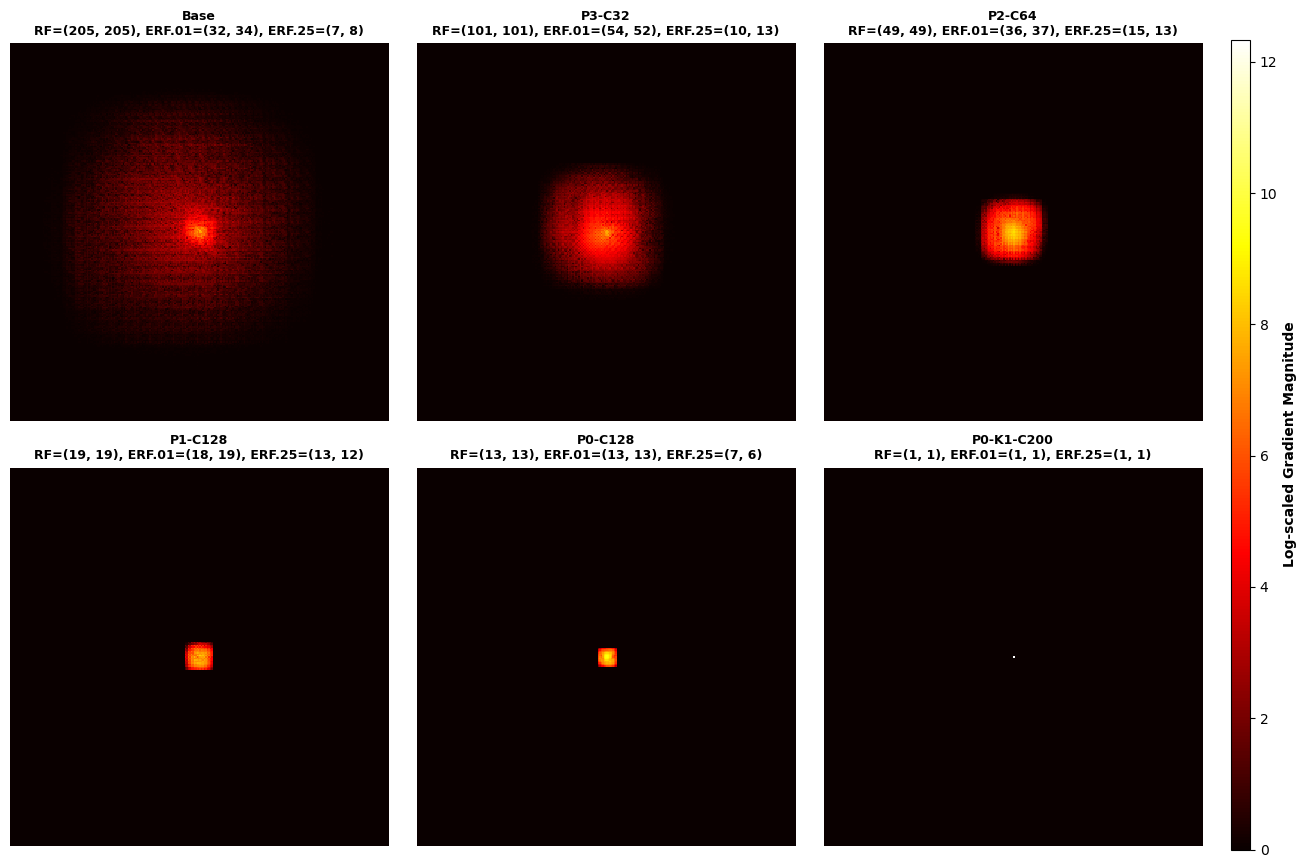

In [6]:
model1_path = 'trained_models/segmentation/unet_base.pth'
model1 = UNetBase(n_channels=3)  
model1.load_state_dict(torch.load(model1_path))

model2_path = 'trained_models/segmentation/unet_pool3.pth'
model2 = UNetPool3(n_channels=3)  
model2.load_state_dict(torch.load(model2_path))

model3_path = 'trained_models/segmentation/unet_pool2.pth'
model3 = UNetPool2(n_channels=3)  
model3.load_state_dict(torch.load(model3_path))

model4_path = 'trained_models/segmentation/unet_pool1.pth'
model4 = UNetPool1(n_channels=3)  
model4.load_state_dict(torch.load(model4_path))

model5_path = 'trained_models/segmentation/unet_pool0.pth'
model5 = UNetPool0(n_channels=3)  
model5.load_state_dict(torch.load(model5_path))

model6_path = 'trained_models/segmentation/unet_pool0_1x1.pth'
model6 = UNetRF1(n_channels=3)  
model6.load_state_dict(torch.load(model6_path))

models = [model1, model2, model3, model4, model5, model6]
titles = ['Base', 'P3-C32', 'P2-C64', 'P1-C128', 'P0-C128', 'P0-K1-C200']

compute_receptive_field_grid(models, titles)

In [44]:
def compute_encoder_receptive_fields(encoder, input_shape=(1, 13, 128, 128), visualize=False):
    encoder.eval()
    x = torch.zeros(input_shape, requires_grad=True)

    features = encoder(x)
    results = []

    for i, feat in enumerate(features):
        print(f"Stage {i}: feature shape = {feat.shape}")

        if feat.shape[2] == 0 or feat.shape[3] == 0:
            results.append({'stage': i, 'rf': (0, 0)})
            continue

        grad_mask = torch.zeros_like(feat)
        center_y = feat.shape[2] // 2
        center_x = feat.shape[3] // 2
        grad_mask[0, :, center_y, center_x] = 1.0  # all channels at center pixel

        encoder.zero_grad()
        if x.grad is not None:
            x.grad.zero_()

        try:
            feat.backward(gradient=grad_mask, retain_graph=True)
        except RuntimeError as e:
            print(f"Backward failed at stage {i}: {e}")
            results.append({'stage': i, 'rf': (0, 0)})
            continue

        grad = x.grad[0].abs().sum(dim=0)

        coords = torch.nonzero(grad > 0, as_tuple=False)
        if coords.shape[0] == 0:
            rf = (0, 0)
        else:
            min_yx = coords.min(dim=0).values
            max_yx = coords.max(dim=0).values
            rf = (max_yx - min_yx + 1).tolist()

        if visualize:
            import matplotlib.pyplot as plt
            import numpy as np
            plt.figure()
            plt.imshow(np.log1p(grad.cpu().numpy() * 100), cmap='hot')
            plt.title(f'Stage {i} Receptive Field Heatmap\nRF: {rf}')
            plt.colorbar()
            plt.show()

        results.append({'stage': i, 'rf': rf})

    return results


Stage 0: feature shape = torch.Size([1, 128, 256, 256])


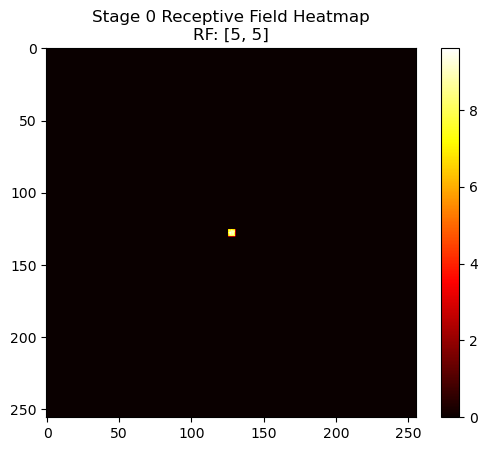

Stage 1: feature shape = torch.Size([1, 128, 128, 128])


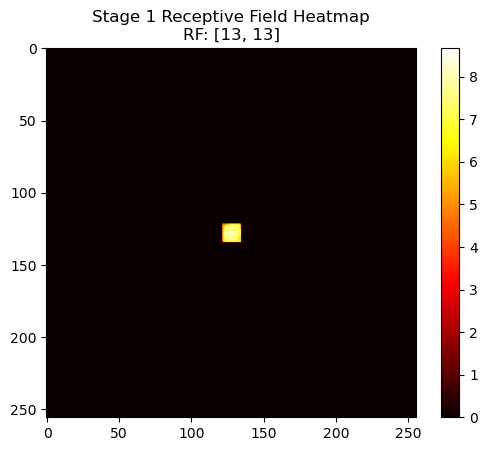

Stage 0: RF = [5, 5]
Stage 1: RF = [13, 13]


In [48]:
model_path = 'trained_models/s1/segmentation/unet_s1_pool1.pth'
model = UNetPool1(n_channels=2)  # n_channels based on model
model.load_state_dict(torch.load(model_path))
encoder = model.encoder
#encoder = EncoderBase(in_channels=13)
rf_info = compute_encoder_receptive_fields(encoder, input_shape=(1, 2, 256, 256), visualize=True)

for r in rf_info:
    print(f"Stage {r['stage']}: RF = {r['rf']}")
